In [9]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.1/932.1 kB 17.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
btc = pd.read_parquet("btc_daily.parquet").copy()
btc = btc.dropna(subset=["Close"])

btc["return"] = np.log(btc["Close"] / btc["Close"].shift(1))
btc = btc.dropna()
btc["return_pct"] = btc["return"] * 100

btc.head()

,Open,High,Low,Close,Volume,return,return_pct
datetime,,,,,,,
2012-01-02,4.84,5.00,4.84,5.00,10.100000,0.032523,3.252319
2012-01-03,5.00,5.32,5.00,5.29,107.085281,0.056380,5.638033
2012-01-04,5.29,5.57,4.93,5.57,107.233260,0.051577,5.157681
2012-01-05,5.57,6.46,5.57,6.42,70.328742,0.142023,14.202306
2012-01-06,6.42,6.90,6.40,6.40,55.855834,-0.003120,-0.312013


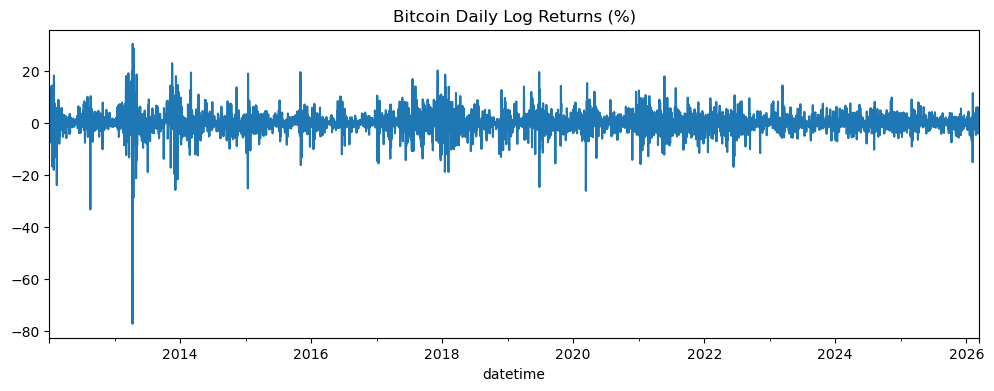

In [19]:
# Plot Returns

btc["return_pct"].plot(figsize=(12, 4), title="Bitcoin Daily Log Returns (%)")
plt.show()

In [21]:
# Train-test Split

split_idx = int(len(btc) * 0.8)

train = btc.iloc[:split_idx].copy()
test = btc.iloc[split_idx:].copy()

print("Train start:", train.index.min())
print("Train end:", train.index.max())
print("Test start:", test.index.min())
print("Test end:", test.index.max())

Train start: 2012-01-02 00:00:00
Train end: 2023-05-11 00:00:00
Test start: 2023-05-12 00:00:00
Test end: 2026-03-13 00:00:00


In [23]:
# Fit GARCH(1,1)

garch_model = arch_model(
    train["return_pct"],
    vol="GARCH",
    p=1,
    q=1,
    mean="constant",
    dist="normal"
)

garch_res = garch_model.fit(disp="off")
print(garch_res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             return_pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -11195.5
Distribution:                  Normal   AIC:                           22399.0
Method:            Maximum Likelihood   BIC:                           22424.4
                                        No. Observations:                 4148
Date:                Fri, Mar 13 2026   Df Residuals:                     4147
Time:                        18:43:41   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1289  4.621e-02      2.790  5.270e-03 [3.836e-0

In [25]:
# Fit GJR-GARCH

gjr_model = arch_model(
    train["return_pct"],
    vol="GARCH",
    p=1,
    o=1,
    q=1,
    mean="constant",
    dist="normal"
)

gjr_res = gjr_model.fit(disp="off")
print(gjr_res.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:             return_pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -11194.3
Distribution:                  Normal   AIC:                           22398.7
Method:            Maximum Likelihood   BIC:                           22430.3
                                        No. Observations:                 4148
Date:                Fri, Mar 13 2026   Df Residuals:                     4147
Time:                        18:44:52   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1438  4.584e-02      3.138  1.703e-03 [5.399e-0

In [27]:
# Fit EGARCH

egarch_model = arch_model(
    train["return_pct"],
    vol="EGARCH",
    p=1,
    q=1,
    mean="constant",
    dist="normal"
)

egarch_res = egarch_model.fit(disp="off")
print(egarch_res.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:             return_pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -11186.7
Distribution:                  Normal   AIC:                           22381.4
Method:            Maximum Likelihood   BIC:                           22406.7
                                        No. Observations:                 4148
Date:                Fri, Mar 13 2026   Df Residuals:                     4147
Time:                        18:45:18   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.1323  1.035e-02     12.779  2.143e-37 [  0.112,  0.15

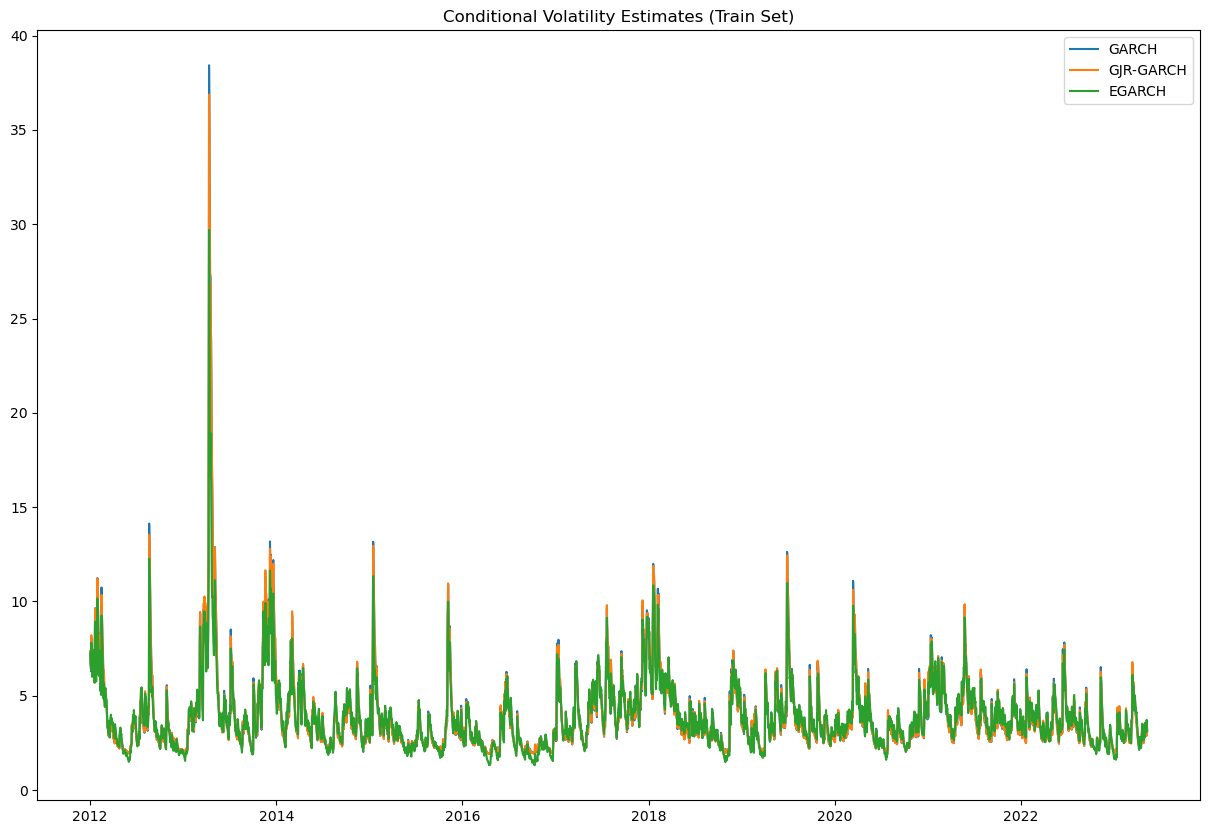

In [31]:
# Compare in-sample conditional volatility

train["garch_vol"] = garch_res.conditional_volatility
train["gjr_vol"] = gjr_res.conditional_volatility
train["egarch_vol"] = egarch_res.conditional_volatility

plt.figure(figsize=(15, 10))
plt.plot(train.index, train["garch_vol"], label="GARCH")
plt.plot(train.index, train["gjr_vol"], label="GJR-GARCH")
plt.plot(train.index, train["egarch_vol"], label="EGARCH")
plt.title("Conditional Volatility Estimates (Train Set)")
plt.legend()
plt.show()

In [33]:
# Model comparison with AIC / BIC

comparison = pd.DataFrame({
    "Model": ["GARCH", "GJR-GARCH", "EGARCH"],
    "AIC": [garch_res.aic, gjr_res.aic, egarch_res.aic],
    "BIC": [garch_res.bic, gjr_res.bic, egarch_res.bic]
})

comparison.sort_values("AIC")

,Model,AIC,BIC
2,EGARCH,22381.410625,22406.732151
1,GJR-GARCH,22398.663847,22430.315755
0,GARCH,22399.029247,22424.350773


In [35]:
# Forecast volatility on test set

garch_forecast = garch_res.forecast(horizon=1, start=test.index[0], reindex=False)
gjr_forecast = gjr_res.forecast(horizon=1, start=test.index[0], reindex=False)
egarch_forecast = egarch_res.forecast(horizon=1, start=test.index[0], reindex=False)

In [37]:
# Rolling forecast function

def rolling_vol_forecast(series, model_type="GARCH", p=1, o=0, q=1):
    forecasts = []
    index = []

    for i in range(split_idx, len(series)):
        train_slice = series.iloc[:i]

        model = arch_model(
            train_slice,
            vol=model_type,
            p=p,
            o=o,
            q=q,
            mean="constant",
            dist="normal"
        )

        res = model.fit(disp="off")
        fcast = res.forecast(horizon=1, reindex=False)

        # variance forecast -> volatility forecast
        pred_var = fcast.variance.values[-1, 0]
        pred_vol = np.sqrt(pred_var)

        forecasts.append(pred_vol)
        index.append(series.index[i])

    return pd.Series(forecasts, index=index)

In [39]:
# Generate Forecasts

returns_series = btc["return_pct"]

garch_test_vol = rolling_vol_forecast(
    returns_series,
    model_type="GARCH",
    p=1,
    o=0,
    q=1
)

gjr_test_vol = rolling_vol_forecast(
    returns_series,
    model_type="GARCH",
    p=1,
    o=1,
    q=1
)

egarch_test_vol = rolling_vol_forecast(
    returns_series,
    model_type="EGARCH",
    p=1,
    o=0,
    q=1
)

In [45]:
# Create realized volatility proxy

realized_vol = (btc["return_pct"] ** 2).iloc[split_idx:]

In [47]:
# Evaluate forecast accuracy

eval_df = pd.DataFrame({
    "realized_vol": realized_vol,
    "garch": garch_test_vol,
    "gjr_garch": gjr_test_vol,
    "egarch": egarch_test_vol
}).dropna()

results = pd.DataFrame({
    "Model": ["GARCH", "GJR-GARCH", "EGARCH"],
    "MAE": [
        mean_absolute_error(eval_df["realized_vol"], eval_df["garch"]),
        mean_absolute_error(eval_df["realized_vol"], eval_df["gjr_garch"]),
        mean_absolute_error(eval_df["realized_vol"], eval_df["egarch"])
    ],
    "MSE": [
        mean_squared_error(eval_df["realized_vol"], eval_df["garch"]),
        mean_squared_error(eval_df["realized_vol"], eval_df["gjr_garch"]),
        mean_squared_error(eval_df["realized_vol"], eval_df["egarch"])
    ]
})

results.sort_values("MAE")

,Model,MAE,MSE
0,GARCH,5.726505,193.032824
1,GJR-GARCH,5.728153,193.131912
2,EGARCH,5.742544,192.693047


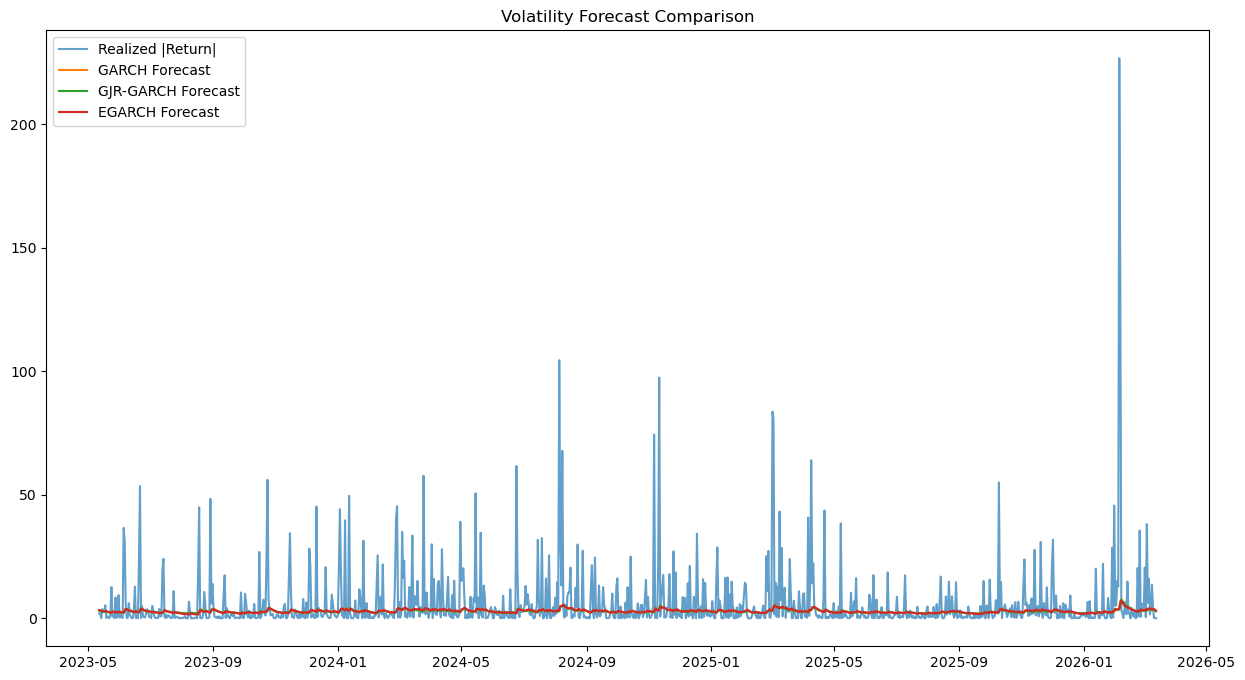

In [51]:
# Plot forecast comparison

plt.figure(figsize=(15, 8))
plt.plot(eval_df.index, eval_df["realized_vol"], label="Realized |Return|", alpha=0.7)
plt.plot(eval_df.index, eval_df["garch"], label="GARCH Forecast")
plt.plot(eval_df.index, eval_df["gjr_garch"], label="GJR-GARCH Forecast")
plt.plot(eval_df.index, eval_df["egarch"], label="EGARCH Forecast")
plt.title("Volatility Forecast Comparison")
plt.legend()
plt.show()